# Week 3 Day 6 — Attention: Query / Key / Value
**Jul 18, 2026**

Every model so far has treated its input as a fixed-size vector or grid. Attention is built for **sequences**, where each position can look at every other position and decide, dynamically, how much to weight it. Today: implement scaled dot-product self-attention from scratch, and check it against PyTorch's own built-in implementation as an oracle — the same "verify your manual math against autograd" trick from Week 1 Day 4, applied here to a trickier mechanism.

Scaffold as usual: TODO stubs, hints not formulas, self-check cells.

## Part 1: Toy sequence data

Given. A batch of random sequences — think of each as `seq_len` tokens, each represented by a `d_model`-dimensional vector (the output of some earlier embedding step you're not building today).

In [1]:
import torch
import torch.nn as nn
import math

torch.manual_seed(0)
batch, seq_len, d_model = 2, 5, 8

x = torch.randn(batch, seq_len, d_model)
print(x.shape)

torch.Size([2, 5, 8])


## Part 2: Why the scores get divided by `sqrt(d_k)`

Given -- a demonstration before you build anything, since this scaling factor is easy to treat as an arbitrary magic constant otherwise. Dot products of two random `d`-dimensional vectors grow in typical magnitude as `d` grows (each of the `d` terms contributes independent variance, and they sum). Larger raw scores pushed through `softmax` make it increasingly saturated -- concentrating almost all weight on a single position, everywhere, regardless of whether that's actually the most relevant position.

In [2]:
Q_demo = torch.randn(seq_len, 64)  # deliberately larger d to make the effect obvious
K_demo = torch.randn(seq_len, 64)

scores_unscaled = Q_demo @ K_demo.T
scores_scaled = scores_unscaled / (64 ** 0.5)

print("unscaled scores std:", scores_unscaled.std().item())
print("scaled scores std:  ", scores_scaled.std().item())

w_unscaled = torch.softmax(scores_unscaled, dim=-1)
w_scaled = torch.softmax(scores_scaled, dim=-1)
print("avg max attention weight, unscaled:", w_unscaled.max(dim=-1).values.mean().item())
print("avg max attention weight, scaled:  ", w_scaled.max(dim=-1).values.mean().item())

unscaled scores std: 7.79970121383667
scaled scores std:   0.9749626517295837
avg max attention weight, unscaled: 0.9897011518478394
avg max attention weight, scaled:   0.4599241316318512


Unscaled, the average "winning" position grabs the vast majority of the attention weight almost regardless of the actual query-key relationship — the softmax is saturated by scale alone, not by genuine relevance. Dividing by `sqrt(d_k)` (the query/key dimension) counteracts exactly the variance growth that causes this, keeping scores in a range where `softmax` can meaningfully discriminate between positions.

## Part 3: Implement self-attention

TODO: build `SelfAttention(d_model)` with three `nn.Linear(d_model, d_model)` projections (`q_proj`, `k_proj`, `v_proj`) and a `forward(x)` that returns `(output, attention_weights)`.

The mechanism, not the code:
1. Project `x` through each of the three linear layers to get `Q`, `K`, `V` — same input, three different learned views of it.
2. Compute raw scores: for every query position, its dot product against every key position. Given `Q` and `K` both shaped `(batch, seq_len, d_model)`, which matrix multiply (and which transpose) produces a `(batch, seq_len, seq_len)` result — "every query against every key"?
3. Scale by `sqrt(d_model)` (Part 2), then `softmax` — but along the *correct* axis. Each query's row should become a probability distribution over keys; check which axis that actually is.
4. Use those weights to combine `V`: for each query position, its output is a weighted average of every position's value vector, weighted by that query's attention distribution.

In [3]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        # TODO: self.q_proj, self.k_proj, self.v_proj
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        # TODO: return (output, attention_weights)
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))  # scaled dot-product attention
        weights = scores.softmax(dim=-1)
        output = weights @ v
        return output, weights

attn = SelfAttention(d_model)
out, weights = attn(x)

assert out.shape == (batch, seq_len, d_model), f"expected {(batch, seq_len, d_model)}, got {tuple(out.shape)}"
assert weights.shape == (batch, seq_len, seq_len), f"expected {(batch, seq_len, seq_len)}, got {tuple(weights.shape)}"

row_sums = weights.sum(dim=-1)
assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5), "each query's weights should sum to 1"

print("shapes OK, weights sum to 1 per query")

shapes OK, weights sum to 1 per query


## Part 4: Check against PyTorch's own implementation

Given, once Part 3 works. `torch.nn.functional.scaled_dot_product_attention` is PyTorch's built-in, optimized version of exactly this computation. Feeding it the *same* `Q`, `K`, `V` your projections produced should give (numerically) the same output as your `forward` -- this isolates whether your attention math itself is correct, independent of the projections.

In [4]:
import torch.nn.functional as F

Q = attn.q_proj(x)
K = attn.k_proj(x)
V = attn.v_proj(x)
reference_out = F.scaled_dot_product_attention(Q, K, V)

assert torch.allclose(out, reference_out, atol=1e-5), "doesn't match F.scaled_dot_product_attention -- check the scaling factor and softmax axis"
print("matches PyTorch's built-in scaled_dot_product_attention")

matches PyTorch's built-in scaled_dot_product_attention


## Part 5: Look at the attention weights

Given. A heatmap of one sequence's `seq_len x seq_len` attention matrix -- row `i`, column `j` is "how much position `i` attends to position `j`."

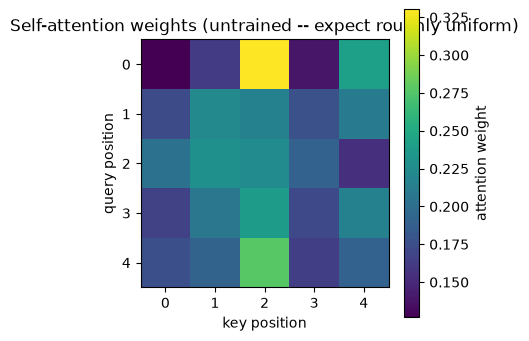

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.imshow(weights[0].detach().numpy(), cmap="viridis")
plt.colorbar(label="attention weight")
plt.xlabel("key position"); plt.ylabel("query position")
plt.title("Self-attention weights (untrained -- expect roughly uniform)")
plt.show()

With random, untrained projections, expect this to look close to uniform -- there's no learned notion of relevance yet. The structure that makes attention useful only emerges once `q_proj`/`k_proj`/`v_proj` are trained on an actual task, which is what Day 7's full encoder block will start to build toward.

## Try yourself

1. Implement a **causal mask**: before the `softmax`, set every score where `key position > query position` to `-inf` (so `softmax` sends that position's weight to exactly 0). Plot the resulting weight matrix -- it should come out lower-triangular. This is the mechanism that makes a model unable to "see the future" in autoregressive generation.
2. Split `d_model` into `num_heads` equal chunks, run the same attention mechanism independently per chunk, and concatenate the results back to `d_model` -- a first pass at multi-head attention, which Day 7 will build properly.
3. Manually scale up one row of `K` by 100x before computing attention (simulating one "key" being unusually salient) and see how dramatically it dominates every query's attention distribution, even for queries that shouldn't logically relate to it.
4. Remove the `sqrt(d_model)` scaling entirely and re-run Part 5's heatmap on a larger `d_model` (e.g. 64) -- does the visualization confirm Part 2's saturation claim?